dataset loading

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from bs4 import BeautifulSoup

df = pd.read_csv("IMDB Dataset.csv")
df.shape
df.head()
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

class balance

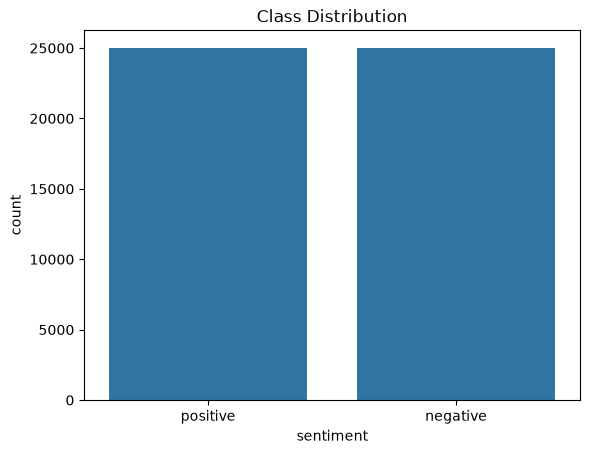

In [2]:
sns.countplot(x='sentiment', data=df)
plt.title("Class Distribution")
plt.show()

Review Length distribution

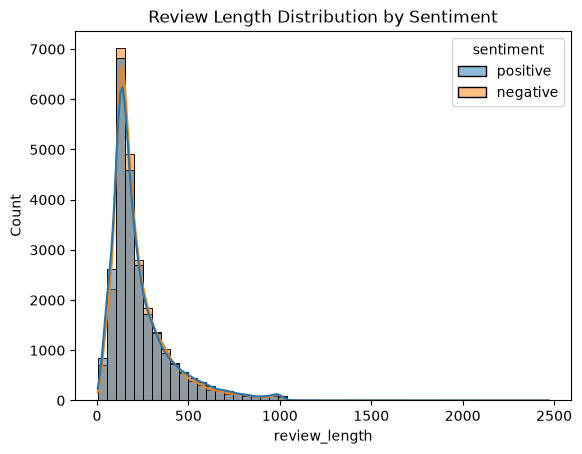

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,25000.0,229.46456,164.947795,4.0,128.0,174.0,278.0,1522.0
positive,25000.0,232.84932,177.497046,10.0,125.0,172.0,284.0,2470.0


In [3]:
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

sns.histplot(data=df, x='review_length', hue='sentiment', bins=50, kde=True)
plt.title("Review Length Distribution by Sentiment")
plt.show()

df.groupby('sentiment')['review_length'].describe()

data quality chek

In [ ]:
print(df.isnull().sum())                        # missing values
print(df.duplicated().sum())                     # duplicate reviews
print(df['review'].str.contains('<br').sum())    # HTML tags?

review           0
sentiment        0
review_length    0
dtype: int64
418
29200


wordcloud

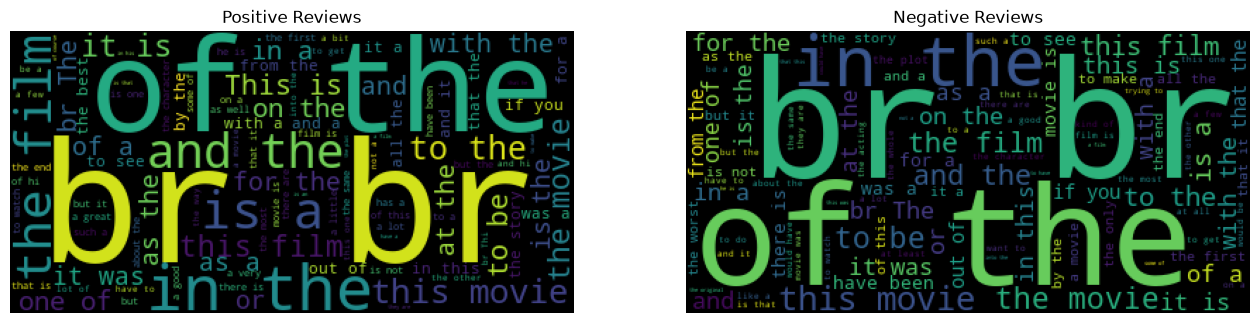

In [5]:
from wordcloud import WordCloud

pos_text = " ".join(df[df.sentiment=='positive']['review'])
neg_text = " ".join(df[df.sentiment=='negative']['review'])

fig, ax = plt.subplots(1, 2, figsize=(16,8))
ax[0].imshow(WordCloud(stopwords='english', max_words=100).generate(pos_text))
ax[0].set_title("Positive Reviews")
ax[0].axis('off')
ax[1].imshow(WordCloud(stopwords='english', max_words=100).generate(neg_text))
ax[1].set_title("Negative Reviews")
ax[1].axis('off')
plt.show()

number of

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=20)
bigrams = cv.fit_transform(df['review'])
freqs = zip(cv.get_feature_names_out(), bigrams.sum(axis=0).tolist()[0])
sorted(freqs, key=lambda x: x[1], reverse=True)

[('br br', 101188),
 ('ve seen', 4168),
 ('br film', 3007),
 ('br movie', 2992),
 ('movie br', 2358),
 ('special effects', 2249),
 ('don know', 2201),
 ('film br', 2079),
 ('low budget', 1824),
 ('looks like', 1677),
 ('year old', 1598),
 ('waste time', 1524),
 ('movie just', 1523),
 ('good movie', 1502),
 ('sci fi', 1393),
 ('watch movie', 1360),
 ('new york', 1315),
 ('look like', 1311),
 ('don think', 1301),
 ('br 10', 1273)]

cleaning the dataset

In [ ]:
def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text() 
    text = re.sub(r'[^a-zA-Z\s]', '', text)                 
    text = text.lower()                                      
    return text

df['clean_review'] = df['review'].apply(clean_text)
df['label'] = df['sentiment'].map({'positive':1, 'negative':0})

# check before/after
print(df['review'][0])
print(df['clean_review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['final_review'] = df['clean_review'].apply(preprocess)


print(df['final_review'][0])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home manyaryans muslim gangsta latino christian italian irish moreso scuffle death stare dodgy dealing shady agreement never far awayi would say main appeal show due fact go show wouldnt dare forget pretty picture painted mainstream audience forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard wholl sold nickel inmate wholl kill order get away well mannered middle class inmate turned prison bitc

In [5]:
df.to_csv('imdb_cleaned.csv', index=False)
print("Saved! Check your folder for imdb_cleaned.csv")

Saved! Check your folder for imdb_cleaned.csv
